# N9 — Late Fusion (M3)

Combines M1 (financial kNN) and M2 (text kNN) via two fusion methods:

1. **Weighted Rank Fusion** — alpha-weighted combination of rank scores
2. **Reciprocal Rank Fusion (RRF)** — parameter-free rank fusion as robustness check

Alpha optimised on `VALIDATION_YEARS = [2020, 2021, 2022]` only.
`TEST_YEARS = [2023, 2024]` never touched during tuning.

**Input:** `peers_m1.parquet` (N6), `peers_m2.parquet` (N8), `multiples.parquet` (N4)
**Output:** `peers_m3.parquet`, `alpha_optimal.json`


In [1]:
# Cell 1 — imports & config
import sys
from pathlib import Path

# Robust config path resolution
notebook_dir = Path('__file__').parent if '__file__' in dir() else Path.cwd()
repo_root = next(
    (p for p in [notebook_dir, *notebook_dir.parents]
     if (p / 'config.py').exists()),
    None
)
if repo_root is None:
    raise FileNotFoundError("config.py not found — check repo structure")
sys.path.insert(0, str(repo_root))

from config import *
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
    print("scipy loaded.")
except ImportError:
    SCIPY_AVAILABLE = False
    print("WARNING: scipy not available — Wilcoxon tests will be skipped.")

try:
    from sklearn.metrics.pairwise import cosine_similarity
    SKLEARN_AVAILABLE = True
    print("sklearn loaded.")
except ImportError:
    SKLEARN_AVAILABLE = False
    print("WARNING: sklearn not available — early fusion cell will be skipped.")

np.random.seed(RANDOM_SEED)

print("Config loaded.")
print(f"  PEERS_M1        : {PEERS_M1}")
print(f"  PEERS_M2        : {PEERS_M2}")
print(f"  PEERS_M3        : {PEERS_M3}")
print(f"  ALPHA_OPTIMAL   : {ALPHA_OPTIMAL}")
print(f"  VALIDATION_YEARS: {VALIDATION_YEARS}")
print(f"  TEST_YEARS      : {TEST_YEARS}")
print(f"  FUSION_METHOD   : {FUSION_METHOD}")
print(f"  ALPHA_GRID      : {ALPHA_GRID}")

Config loaded.
  PEERS_M1        : /work/Repo/data/results/peers_m1.parquet
  PEERS_M2        : /work/Repo/data/results/peers_m2.parquet
  PEERS_M3        : /work/Repo/data/results/peers_m3.parquet
  ALPHA_OPTIMAL   : /work/Repo/data/results/alpha_optimal.json
  VALIDATION_YEARS: [2020, 2021, 2022]
  TEST_YEARS      : [2023, 2024]
  FUSION_METHOD   : weighted_rank
  ALPHA_GRID      : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


In [2]:
# Cell 2 — declare I/O
INPUTS  = [PEERS_M1, PEERS_M2, MULTIPLES]
OUTPUTS = [PEERS_M3, ALPHA_OPTIMAL]
# PURPOSE : Alpha optimisation on validation years, M3 fusion for all years
# RUNTIME : ~5 min
# DEPENDS : peers_m1.parquet (N6), peers_m2.parquet (N8), multiples.parquet (N4)


## 1. Load Data

In [3]:
# Cell 3 — load peers and multiples
peers_m1 = pd.read_parquet(PEERS_M1).dropna(subset=['focal_tic','peer_tic'])
peers_m2 = pd.read_parquet(PEERS_M2).dropna(subset=['focal_tic','peer_tic'])
multiples = pd.read_parquet(MULTIPLES)

print(f"M1 peers : {len(peers_m1):,} records")
print(f"M2 peers : {len(peers_m2):,} records")
print(f"Multiples: {len(multiples):,} firm-years")
print()

# Coverage overlap — firms with BOTH M1 and M2 peers
m1_firms = set(zip(peers_m1['focal_tic'], peers_m1['focal_fyear']))
m2_firms = set(zip(peers_m2['focal_tic'], peers_m2['focal_fyear']))
overlap  = m1_firms & m2_firms
print(f"M1 focal firm-years : {len(m1_firms):,}")
print(f"M2 focal firm-years : {len(m2_firms):,}")
print(f"Overlap (fuseable)  : {len(overlap):,} "
      f"({len(overlap)/len(m1_firms)*100:.1f}% of M1)")


M1 peers : 271,180 records
M2 peers : 271,180 records
Multiples: 20,883 firm-years

M1 focal firm-years : 13,559
M2 focal firm-years : 13,559
Overlap (fuseable)  : 13,559 (100.0% of M1)


## 2. Fusion Functions

In [4]:
# Cell 4 — weighted rank fusion
def weighted_rank_fusion(peers_m1, peers_m2, alpha, k_max=20):
    """
    Fuse M1 and M2 peer lists using alpha-weighted rank scores.

    Score = alpha * (1/rank_text) + (1-alpha) * (1/rank_financial)

    Higher score = better peer. Re-rank by descending score.

    Parameters
    ----------
    alpha : float  weight on text (M2). alpha=0 → pure M1, alpha=1 → pure M2
    """
    # Rank scores: 1/rank so rank-1 peer gets highest score
    m1 = peers_m1[peers_m1['rank'] <= k_max][
        ['focal_tic','focal_fyear','peer_tic','rank']
    ].copy()
    m1['score_fin'] = 1.0 / m1['rank']

    m2 = peers_m2[peers_m2['rank'] <= k_max][
        ['focal_tic','focal_fyear','peer_tic','rank']
    ].copy()
    m2['score_txt'] = 1.0 / m2['rank']

    # Outer join — firms appearing in only one list get 0 for the other
    merged = m1.merge(
        m2[['focal_tic','focal_fyear','peer_tic','score_txt']],
        on=['focal_tic','focal_fyear','peer_tic'], how='outer'
    )
    merged['score_fin'] = merged['score_fin'].fillna(0.0)
    merged['score_txt'] = merged['score_txt'].fillna(0.0)
    merged['fused_score'] = alpha * merged['score_txt'] + (1-alpha) * merged['score_fin']

    # Re-rank by descending fused score per focal firm-year
    merged = merged.sort_values(
        ['focal_tic','focal_fyear','fused_score'], ascending=[True,True,False]
    )
    merged['rank'] = merged.groupby(['focal_tic','focal_fyear']).cumcount() + 1

    merged = merged[merged['rank'] <= k_max].copy()
    merged['similarity_score'] = merged['fused_score']
    merged['model'] = 'M3_Fusion'

    return merged[PEER_SCHEMA]


def reciprocal_rank_fusion(peers_m1, peers_m2, k_max=20, rrf_k=RRF_K_CONSTANT):
    """
    Reciprocal Rank Fusion (Cormack et al. 2009).

    RRF score = 1/(rrf_k + rank_financial) + 1/(rrf_k + rank_text)

    Parameter-free — rrf_k=60 is the standard constant.
    Used as robustness check alongside weighted rank fusion.
    """
    m1 = peers_m1[peers_m1['rank'] <= k_max][
        ['focal_tic','focal_fyear','peer_tic','rank']
    ].copy()
    m1['rrf_fin'] = 1.0 / (rrf_k + m1['rank'])

    m2 = peers_m2[peers_m2['rank'] <= k_max][
        ['focal_tic','focal_fyear','peer_tic','rank']
    ].copy()
    m2['rrf_txt'] = 1.0 / (rrf_k + m2['rank'])

    merged = m1.merge(
        m2[['focal_tic','focal_fyear','peer_tic','rrf_txt']],
        on=['focal_tic','focal_fyear','peer_tic'], how='outer'
    )
    merged['rrf_fin'] = merged['rrf_fin'].fillna(0.0)
    merged['rrf_txt'] = merged['rrf_txt'].fillna(0.0)
    merged['fused_score'] = merged['rrf_fin'] + merged['rrf_txt']

    merged = merged.sort_values(
        ['focal_tic','focal_fyear','fused_score'], ascending=[True,True,False]
    )
    merged['rank'] = merged.groupby(['focal_tic','focal_fyear']).cumcount() + 1
    merged = merged[merged['rank'] <= k_max].copy()
    merged['similarity_score'] = merged['fused_score']
    merged['model'] = 'M3_Fusion_RRF'

    return merged[['focal_tic','focal_fyear','peer_tic','rank',
                   'similarity_score','model']]


print("Fusion functions defined:")
print("  weighted_rank_fusion() — alpha-weighted, optimised on validation years")
print("  reciprocal_rank_fusion() — RRF k=60, parameter-free robustness check")


Fusion functions defined:
  weighted_rank_fusion() — alpha-weighted, optimised on validation years
  reciprocal_rank_fusion() — RRF k=60, parameter-free robustness check


## 3. Evaluation Helper

In [5]:
# Cell 5 — MdAPE helper (same logic as N10)
def compute_mdape(peers_df, multiples_df, multiple_col, k):
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()

    mult_lookup = multiples_df[['tic','fyear',multiple_col]].dropna(subset=[multiple_col])

    peers_k = peers_k.merge(
        mult_lookup.rename(columns={'tic':'peer_tic','fyear':'focal_fyear',
                                    multiple_col:'peer_multiple'}),
        on=['peer_tic','focal_fyear'], how='inner'
    )
    predicted = (peers_k.groupby(['focal_tic','focal_fyear'])['peer_multiple']
                         .median().reset_index()
                         .rename(columns={'peer_multiple':'predicted'}))
    predicted = predicted.merge(
        mult_lookup.rename(columns={'tic':'focal_tic','fyear':'focal_fyear',
                                    multiple_col:'actual'}),
        on=['focal_tic','focal_fyear'], how='inner'
    )
    predicted['ape'] = ((predicted['actual'] - predicted['predicted']).abs() /
                        predicted['actual'].abs())
    return predicted['ape'].dropna()

print("compute_mdape() defined.")


compute_mdape() defined.


## 4. Alpha Optimisation — Validation Years Only

In [6]:
# Cell 6 — alpha grid search on VALIDATION_YEARS
peers_m1_val = peers_m1[peers_m1['focal_fyear'].isin(VALIDATION_YEARS)]
peers_m2_val = peers_m2[peers_m2['focal_fyear'].isin(VALIDATION_YEARS)]
multiples_val = multiples[multiples['fyear'].isin(VALIDATION_YEARS)]

print(f"Optimising alpha on VALIDATION_YEARS = {VALIDATION_YEARS}")
print(f"Alpha grid: {ALPHA_GRID}")
print()

alpha_results = []

for alpha in ALPHA_GRID:
    fused_val = weighted_rank_fusion(peers_m1_val, peers_m2_val, alpha, k_max=20)
    errors    = compute_mdape(fused_val, multiples_val, 'ln_v2s', K_MAIN)
    mdape     = np.median(errors)
    alpha_results.append({'alpha': alpha, 'mdape': mdape, 'n': len(errors)})
    print(f"  alpha={alpha:.1f}  MdAPE={mdape*100:.3f}%  n={len(errors):,}")

alpha_df   = pd.DataFrame(alpha_results)
best_alpha = alpha_df.loc[alpha_df['mdape'].idxmin(), 'alpha']
best_mdape = alpha_df['mdape'].min()

print(f"\nBest alpha : {best_alpha}")
print(f"Best MdAPE : {best_mdape*100:.3f}% (validation set)")
print(f"\nNOTE: TEST_YEARS {TEST_YEARS} never touched during optimisation")


Optimising alpha on VALIDATION_YEARS = [2020, 2021, 2022]
Alpha grid: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

  alpha=0.0  MdAPE=43.234%  n=7,944
  alpha=0.1  MdAPE=42.244%  n=7,944
  alpha=0.2  MdAPE=41.126%  n=7,944
  alpha=0.3  MdAPE=40.674%  n=7,944
  alpha=0.4  MdAPE=41.171%  n=7,944
  alpha=0.5  MdAPE=41.622%  n=7,944
  alpha=0.6  MdAPE=42.295%  n=7,944
  alpha=0.7  MdAPE=44.046%  n=7,944
  alpha=0.8  MdAPE=45.922%  n=7,944
  alpha=0.9  MdAPE=48.914%  n=7,944
  alpha=1.0  MdAPE=51.075%  n=7,944

Best alpha : 0.3
Best MdAPE : 40.674% (validation set)

NOTE: TEST_YEARS [2023, 2024] never touched during optimisation


Per-year alpha sensitivity:
-------------------------------------------------------
  2020 | α*=0.3 | MdAPE(α*)=40.261% | MdAPE(M1)=42.084% | MdAPE(M2)=50.574% | n=2,446
  2021 | α*=0.4 | MdAPE(α*)=38.617% | MdAPE(M1)=41.441% | MdAPE(M2)=49.254% | n=2,781
  2022 | α*=0.3 | MdAPE(α*)=42.751% | MdAPE(M1)=46.029% | MdAPE(M2)=53.747% | n=2,717
  2023 | α*=0.3 | MdAPE(α*)=41.490% | MdAPE(M1)=44.346% | MdAPE(M2)=51.000% | n=2,742
  2024 | α*=0.3 | MdAPE(α*)=42.226% | MdAPE(M1)=44.440% | MdAPE(M2)=56.119% | n=2,873

--- Per-Year Summary ---
 Year  Alpha_star  MdAPE_M1  MdAPE_M2  MdAPE_opt  Gain_vs_M1_pp    n     Period
 2020         0.3    42.084    50.574     40.261          1.823 2446 Validation
 2021         0.4    41.441    49.254     38.617          2.823 2781 Validation
 2022         0.3    46.029    53.747     42.751          3.278 2717 Validation
 2023         0.3    44.346    51.000     41.490          2.855 2742       Test
 2024         0.3    44.440    56.119     42.226          2.

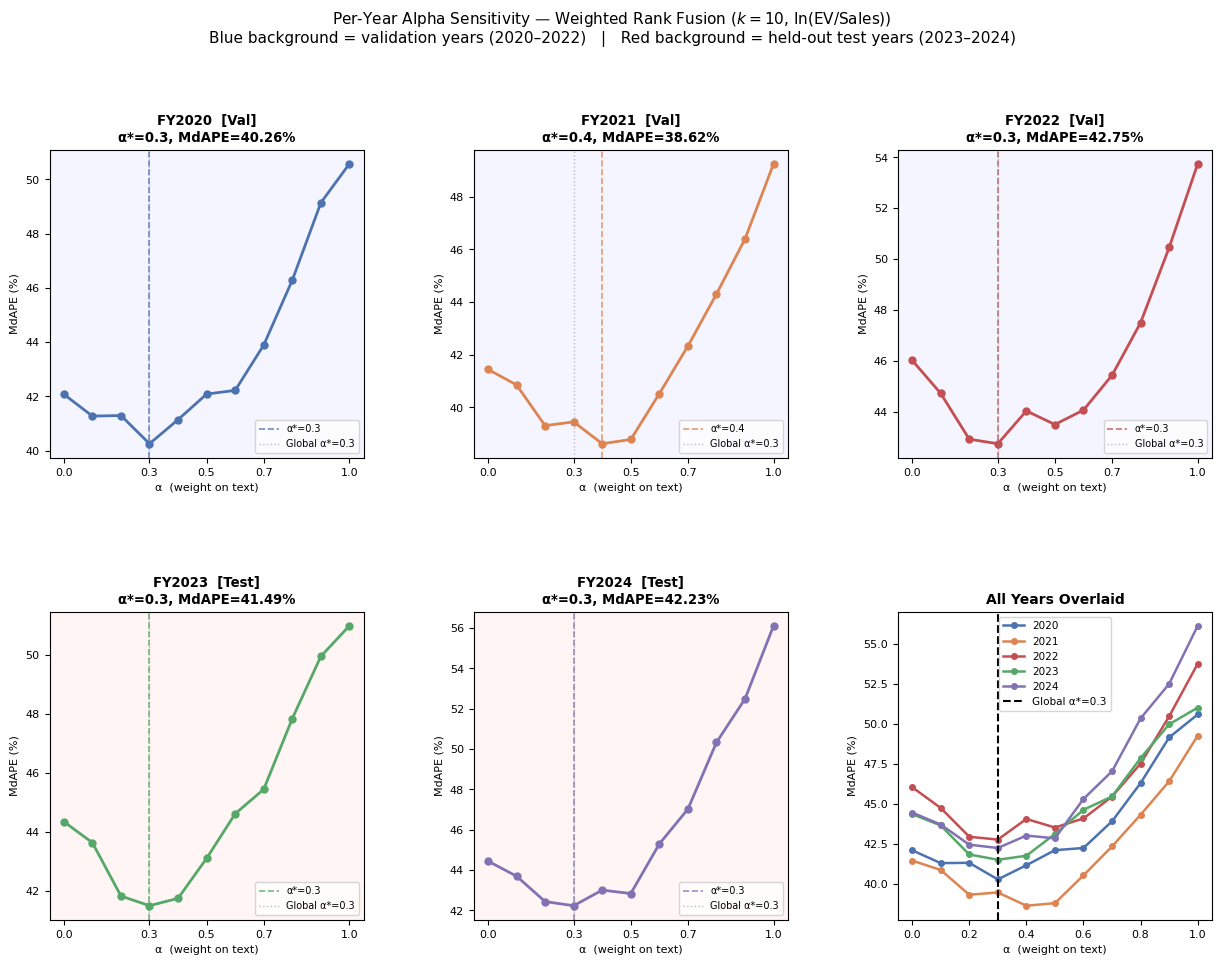

Saved: n9_alpha_sensitivity_yearly.pdf


In [7]:
# Cell 6b — Per-year alpha sensitivity
# Tests whether optimal alpha is structurally stable or regime-dependent
# OUTPUT: yearly_alpha_summary.csv + figure n9_alpha_sensitivity_yearly.pdf

import matplotlib.gridspec as gridspec

YEAR_COLORS = {
    2020: '#4C72B0',
    2021: '#DD8452',
    2022: '#C44E52',
    2023: '#55A868',
    2024: '#8172B3',
}

yearly_results = {}

print("Per-year alpha sensitivity:")
print("-" * 55)

for year in YEARS:
    m1_y    = peers_m1[peers_m1['focal_fyear'] == year]
    m2_y    = peers_m2[peers_m2['focal_fyear'] == year]
    mult_y  = multiples[multiples['fyear'] == year]
    year_d  = {}

    for alpha in ALPHA_GRID:
        fused  = weighted_rank_fusion(m1_y, m2_y, alpha, k_max=20)
        errors = compute_mdape(fused, mult_y, 'ln_v2s', K_MAIN)
        year_d[alpha] = {
            'mdape': float(np.median(errors)),
            'n':     len(errors)
        }

    best_a = min(year_d, key=lambda a: year_d[a]['mdape'])
    yearly_results[year] = year_d

    print(f"  {year} | α*={best_a} | "
          f"MdAPE(α*)={year_d[best_a]['mdape']*100:.3f}% | "
          f"MdAPE(M1)={year_d[0.0]['mdape']*100:.3f}% | "
          f"MdAPE(M2)={year_d[1.0]['mdape']*100:.3f}% | "
          f"n={year_d[best_a]['n']:,}")

# ── Summary table ──────────────────────────────────────────
rows = []
for year, yd in yearly_results.items():
    best_a = min(yd, key=lambda a: yd[a]['mdape'])
    rows.append({
        'Year':           year,
        'Alpha_star':     best_a,
        'MdAPE_M1':       round(yd[0.0]['mdape'] * 100, 3),
        'MdAPE_M2':       round(yd[1.0]['mdape'] * 100, 3),
        'MdAPE_opt':      round(yd[best_a]['mdape'] * 100, 3),
        'Gain_vs_M1_pp':  round((yd[0.0]['mdape'] - yd[best_a]['mdape']) * 100, 3),
        'n':              yd[best_a]['n'],
        'Period':         'Validation' if year in VALIDATION_YEARS else 'Test'
    })

yearly_df = pd.DataFrame(rows)
print("\n--- Per-Year Summary ---")
print(yearly_df.to_string(index=False))
yearly_df.to_csv(DATA_RESULTS / 'yearly_alpha_summary.csv', index=False)

# ── Figure: individual year curves + overlay ───────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(5)]
ax_all = fig.add_subplot(gs[1, 2])

for ax, year in zip(axes, YEARS):
    mdapes = [yearly_results[year][a]['mdape'] * 100 for a in ALPHA_GRID]
    best_a  = min(yearly_results[year], key=lambda a: yearly_results[year][a]['mdape'])
    best_m  = yearly_results[year][best_a]['mdape'] * 100
    bg      = '#fff5f5' if year in TEST_YEARS else '#f5f5ff'

    ax.set_facecolor(bg)
    ax.plot(ALPHA_GRID, mdapes,
            color=YEAR_COLORS[year], lw=2, marker='o', ms=5)
    ax.axvline(best_a,  color=YEAR_COLORS[year], ls='--', lw=1.2, alpha=0.8,
               label=f'α*={best_a}')
    ax.axvline(0.3,     color='grey', ls=':', lw=1.0, alpha=0.5,
               label='Global α*=0.3')
    ax.set_title(f'FY{year}  [{"Test" if year in TEST_YEARS else "Val"}]\n'
                 f'α*={best_a}, MdAPE={best_m:.2f}%',
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('α  (weight on text)', fontsize=8)
    ax.set_ylabel('MdAPE (%)', fontsize=8)
    ax.set_xticks([0.0, 0.3, 0.5, 0.7, 1.0])
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

# Overlay panel
for year in YEARS:
    mdapes = [yearly_results[year][a]['mdape'] * 100 for a in ALPHA_GRID]
    ax_all.plot(ALPHA_GRID, mdapes,
                color=YEAR_COLORS[year], lw=1.8,
                marker='o', ms=4, label=str(year))

ax_all.axvline(0.3, color='black', ls='--', lw=1.5, label='Global α*=0.3')
ax_all.set_title('All Years Overlaid', fontsize=10, fontweight='bold')
ax_all.set_xlabel('α  (weight on text)', fontsize=8)
ax_all.set_ylabel('MdAPE (%)', fontsize=8)
ax_all.legend(fontsize=7.5)
ax_all.tick_params(labelsize=8)

fig.suptitle(
    r'Per-Year Alpha Sensitivity — Weighted Rank Fusion ($k=10$, $\ln(\mathrm{EV/Sales})$)'
    '\nBlue background = validation years (2020–2022)   |   '
    'Red background = held-out test years (2023–2024)',
    fontsize=11, y=1.02
)
plt.savefig(FIGURES / 'n9_alpha_sensitivity_yearly.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: n9_alpha_sensitivity_yearly.pdf")

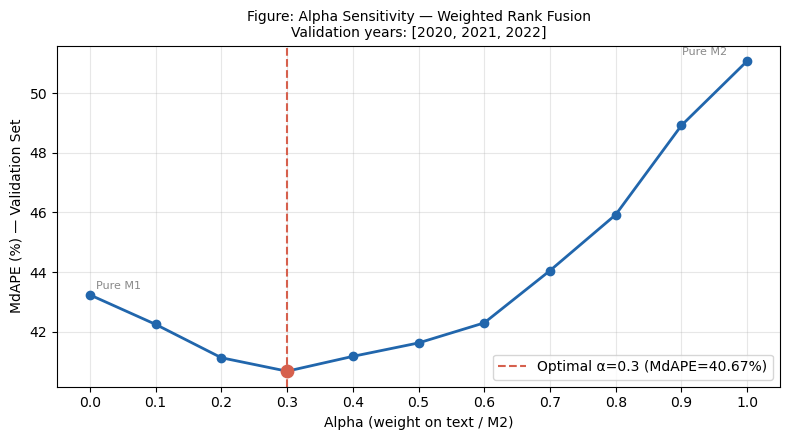

Saved: /work/Repo/figures/n9_alpha_sensitivity.pdf


In [8]:
# Cell 7 — alpha sensitivity plot
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(alpha_df['alpha'], alpha_df['mdape']*100,
        color='#2166ac', marker='o', linewidth=2, markersize=6)
ax.axvline(best_alpha, color='#d6604d', linewidth=1.5,
           linestyle='--', label=f'Optimal α={best_alpha} (MdAPE={best_mdape*100:.2f}%)')
ax.scatter([best_alpha], [best_mdape*100], color='#d6604d', s=80, zorder=5)

ax.set_xlabel('Alpha (weight on text / M2)')
ax.set_ylabel('MdAPE (%) — Validation Set')
ax.set_title('Figure: Alpha Sensitivity — Weighted Rank Fusion\n'
             f'Validation years: {VALIDATION_YEARS}', fontsize=10)
ax.set_xticks(ALPHA_GRID)
ax.legend()
ax.grid(alpha=0.3)

# Label endpoints
ax.text(0.01, alpha_df[alpha_df['alpha']==0.0]['mdape'].values[0]*100+0.2,
        'Pure M1', fontsize=8, color='#888888')
ax.text(0.97, alpha_df[alpha_df['alpha']==1.0]['mdape'].values[0]*100+0.2,
        'Pure M2', fontsize=8, color='#888888', ha='right')

plt.tight_layout()
plt.savefig(FIGURES / 'n9_alpha_sensitivity.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n9_alpha_sensitivity.pdf'}")


In [9]:
# Cell 8 — save alpha_optimal.json
alpha_manifest = {
    'best_alpha'       : best_alpha,
    'best_mdape_val'   : float(best_mdape),
    'validation_years' : VALIDATION_YEARS,
    'test_years'       : TEST_YEARS,
    'fusion_method'    : 'weighted_rank',
    'multiple_used'    : 'ln_v2s',
    'k_used'           : K_MAIN,
    'alpha_grid_results': alpha_df.to_dict(orient='records'),
}

ALPHA_OPTIMAL.parent.mkdir(parents=True, exist_ok=True)
with open(ALPHA_OPTIMAL, 'w') as f:
    json.dump(alpha_manifest, f, indent=2)

print(f"Saved: {ALPHA_OPTIMAL}")
print(f"  best_alpha = {best_alpha}")


Saved: /work/Repo/data/results/alpha_optimal.json
  best_alpha = 0.3


## 5. Build M3 Peers — All Years

In [10]:
# Cell 9 — build M3 (weighted rank) for ALL years using best_alpha
print(f"Building M3 (Weighted Rank Fusion, alpha={best_alpha}) for all years...")
peers_m3_wr = weighted_rank_fusion(peers_m1, peers_m2, best_alpha, k_max=20)
peers_m3_wr['model'] = 'M3_Fusion'
print(f"  M3 (WR) : {len(peers_m3_wr):,} records | "
      f"{peers_m3_wr['focal_tic'].nunique():,} focal firms")

# Build RRF version as robustness check
print(f"Building M3_RRF (Reciprocal Rank Fusion, k={RRF_K_CONSTANT})...")
peers_m3_rrf = reciprocal_rank_fusion(peers_m1, peers_m2, k_max=20)
print(f"  M3 (RRF): {len(peers_m3_rrf):,} records | "
      f"{peers_m3_rrf['focal_tic'].nunique():,} focal firms")


Building M3 (Weighted Rank Fusion, alpha=0.3) for all years...
  M3 (WR) : 271,180 records | 3,494 focal firms
Building M3_RRF (Reciprocal Rank Fusion, k=60)...
  M3 (RRF): 271,180 records | 3,494 focal firms


In [11]:
# Cell 10 — compare WR vs RRF on validation set (sanity check)
print("Sanity check — WR vs RRF on validation years:")
for label, df_fused in [('Weighted Rank', peers_m3_wr), ('RRF', peers_m3_rrf)]:
    val = df_fused[df_fused['focal_fyear'].isin(VALIDATION_YEARS)]
    errors = compute_mdape(val, multiples_val, 'ln_v2s', K_MAIN)
    print(f"  {label:<15} MdAPE={np.median(errors)*100:.3f}%  n={len(errors):,}")


Sanity check — WR vs RRF on validation years:
  Weighted Rank   MdAPE=40.674%  n=7,944
  RRF             MdAPE=41.751%  n=7,944


In [12]:
# Cell 11 — save peers_m3.parquet (primary = weighted rank)
# Also save RRF separately for robustness check in N10
PEERS_M3.parent.mkdir(parents=True, exist_ok=True)
peers_m3_wr.to_parquet(PEERS_M3, index=False)

peers_m3_rrf_path = DATA_RESULTS / "peers_m3_rrf.parquet"
peers_m3_rrf.to_parquet(peers_m3_rrf_path, index=False)

print(f"Saved (primary) : {PEERS_M3}")
print(f"Saved (RRF)     : {peers_m3_rrf_path}")
print()
print("Peer records per year:")
print(peers_m3_wr.groupby('focal_fyear')['focal_tic'].count().to_string())


Saved (primary) : /work/Repo/data/results/peers_m3.parquet
Saved (RRF)     : /work/Repo/data/results/peers_m3_rrf.parquet

Peer records per year:
focal_fyear
2020    48920
2021    55620
2022    54340
2023    54840
2024    57460


In [13]:
# Cell 12 — final summary
print("=" * 60)
print("N9 COMPLETE — FUSION SUMMARY")
print("=" * 60)
print(f"  Optimal alpha    : {best_alpha}")
print(f"    α=0 → pure M1 (financial)")
print(f"    α=1 → pure M2 (text)")
print(f"  Val MdAPE        : {best_mdape*100:.3f}%")
print(f"  Validation years : {VALIDATION_YEARS}")
print(f"  Test years       : {TEST_YEARS} (never touched)")
print()
print(f"  M3 (WR)  records : {len(peers_m3_wr):,}")
print(f"  M3 (RRF) records : {len(peers_m3_rrf):,}")
print()
print(f"  Outputs:")
print(f"    {PEERS_M3}")
print(f"    {DATA_RESULTS / 'peers_m3_rrf.parquet'}")
print(f"    {ALPHA_OPTIMAL}")
print()
print("  Next: N10 — Full evaluation (M0 vs M1 vs M2 vs M3)")


N9 COMPLETE — FUSION SUMMARY
  Optimal alpha    : 0.3
    α=0 → pure M1 (financial)
    α=1 → pure M2 (text)
  Val MdAPE        : 40.674%
  Validation years : [2020, 2021, 2022]
  Test years       : [2023, 2024] (never touched)

  M3 (WR)  records : 271,180
  M3 (RRF) records : 271,180

  Outputs:
    /work/Repo/data/results/peers_m3.parquet
    /work/Repo/data/results/peers_m3_rrf.parquet
    /work/Repo/data/results/alpha_optimal.json

  Next: N10 — Full evaluation (M0 vs M1 vs M2 vs M3)


In [14]:
# Cell 13 — Early Fusion: concatenate financial + text vectors, 
#            compute cosine kNN on combined 832-dim space
# This is the ablation that justifies late fusion as the design choice.
# 
# EXPECTED RESULT: text dominates by dimensionality (768 of 832 dims = 92.3%)
# → early fusion degrades to near-M2 performance regardless of financial content

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# Load raw (non-normalised) embeddings and financial features
df_fin  = pd.read_parquet(FINANCIALS_NORM)
df_emb  = pd.read_parquet(EMBEDDINGS)

with open(SELECTED_FEATURES_FILE) as f:
    feat_manifest = json.load(f)
selected_features = feat_manifest['selected_features']

def build_early_fusion_peers(df_fin, df_emb, selected_features, 
                              fyear, k_max=20):
    """
    Concatenate z-normalised financial vector (64-dim) with L2-normalised
    FinBERT embedding (768-dim) → 832-dim combined vector.
    Compute cosine kNN on combined space.
    """
    fin_yr = (df_fin[df_fin['fyear'] == fyear]
              [['tic'] + selected_features]
              .dropna(subset=['tic'])
              .copy())
    emb_yr = (df_emb[df_emb['fyear'] == fyear]
              .copy())
    emb_cols = [f'emb_{i}' for i in range(EMBEDDING_DIM)]

    # Inner join — only firms with BOTH modalities
    merged = fin_yr.merge(emb_yr[['tic'] + emb_cols], on='tic', how='inner')
    tickers = merged['tic'].values

    # Stack: financial (already z-normalised) | text (already L2-normalised)
    Z_fin = merged[selected_features].values   # 64-dim
    Z_emb = merged[emb_cols].values            # 768-dim
    Z_combined = np.hstack([Z_fin, Z_emb])     # 832-dim

    sim_matrix = cosine_similarity(Z_combined)
    np.fill_diagonal(sim_matrix, -np.inf)

    k = min(k_max, len(tickers) - 1)
    records = []
    for i in range(len(tickers)):
        top_k_idx = np.argpartition(sim_matrix[i], -k)[-k:]
        top_k_idx = top_k_idx[np.argsort(sim_matrix[i][top_k_idx])[::-1]]
        for rank, j in enumerate(top_k_idx, start=1):
            records.append({
                'focal_tic'       : tickers[i],
                'focal_fyear'     : fyear,
                'peer_tic'        : tickers[j],
                'rank'            : rank,
                'similarity_score': float(sim_matrix[i][j]),
                'model'           : 'M_EarlyFusion',
            })
    return pd.DataFrame(records)

print("build_early_fusion_peers() defined.")
print(f"  Combined vector dimension: {len(selected_features) + EMBEDDING_DIM}")
print(f"  Text share of dimensions : "
      f"{EMBEDDING_DIM / (len(selected_features) + EMBEDDING_DIM) * 100:.1f}%")

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Cell 14 — Run early fusion on VALIDATION YEARS and compare to late fusion
# Uses same evaluation logic as alpha grid search for apples-to-apples comparison

print("Building early fusion peer lists on validation years...")
early_fusion_peers = []
for yr in VALIDATION_YEARS:
    peers_ef_yr = build_early_fusion_peers(
        df_fin, df_emb, selected_features, yr, k_max=20
    )
    early_fusion_peers.append(peers_ef_yr)
    print(f"  {yr}: {len(peers_ef_yr):,} records")

peers_ef = pd.concat(early_fusion_peers, ignore_index=True)

# Evaluate on validation set
multiples_val = multiples[multiples['fyear'].isin(VALIDATION_YEARS)]

ef_errors  = compute_mdape(peers_ef,       multiples_val, 'ln_v2s', K_MAIN)
wr_errors  = compute_mdape(
    peers_m3_wr[peers_m3_wr['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)
m1_errors  = compute_mdape(
    peers_m1[peers_m1['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)
m2_errors  = compute_mdape(
    peers_m2[peers_m2['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)

print()
print("=" * 65)
print("FUSION METHOD COMPARISON — Validation Years 2020-2022")
print(f"Primary metric: MdAPE on ln(EV/Sales), k={K_MAIN}")
print("=" * 65)
print(f"  M1 (Financial only, α=0.0)  : {np.median(m1_errors)*100:.3f}%")
print(f"  M2 (Text only,      α=1.0)  : {np.median(m2_errors)*100:.3f}%")
print(f"  Early Fusion (concat 832d)  : {np.median(ef_errors)*100:.3f}%")
print(f"  Late Fusion WR (α=0.3)      : {np.median(wr_errors)*100:.3f}%")
print()

# Wilcoxon: late vs early fusion
from scipy.stats import wilcoxon
merged_ef_wr = (
    pd.DataFrame({'ape': ef_errors.values,
                  'focal_tic': ef_errors.index.get_level_values(0) 
                  if ef_errors.index.nlevels > 1 else range(len(ef_errors))})
)
# Simple paired comparison on matched firm-years
ef_df = compute_mdape(peers_ef, multiples_val, 'ln_v2s', K_MAIN)
wr_df_val = compute_mdape(
    peers_m3_wr[peers_m3_wr['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)

# Rebuild as DataFrames for merging
def compute_mdape_df(peers_df, multiples_df, multiple_col, k):
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()
    mult_lookup = multiples_df[['tic','fyear',multiple_col]].dropna()
    peers_k = peers_k.merge(
        mult_lookup.rename(columns={'tic':'peer_tic','fyear':'focal_fyear',
                                    multiple_col:'peer_multiple'}),
        on=['peer_tic','focal_fyear'], how='inner'
    )
    predicted = (peers_k.groupby(['focal_tic','focal_fyear'])['peer_multiple']
                 .median().reset_index()
                 .rename(columns={'peer_multiple':'predicted'}))
    predicted = predicted.merge(
        mult_lookup.rename(columns={'tic':'focal_tic','fyear':'focal_fyear',
                                    multiple_col:'actual'}),
        on=['focal_tic','focal_fyear'], how='inner'
    )
    predicted['ape'] = ((predicted['actual'] - predicted['predicted']).abs() /
                        predicted['actual'].abs())
    return predicted[['focal_tic','focal_fyear','ape']].dropna()

ef_full  = compute_mdape_df(peers_ef, multiples_val, 'ln_v2s', K_MAIN)
wr_full  = compute_mdape_df(
    peers_m3_wr[peers_m3_wr['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)
m2_full  = compute_mdape_df(
    peers_m2[peers_m2['focal_fyear'].isin(VALIDATION_YEARS)],
    multiples_val, 'ln_v2s', K_MAIN
)

# Merge for paired test
paired = ef_full.merge(wr_full, on=['focal_tic','focal_fyear'],
                       suffixes=('_ef','_wr'))
stat, pval = wilcoxon(paired['ape_ef'], paired['ape_wr'], alternative='greater')

# Compare early fusion to M2 (text only)
paired_ef_m2 = ef_full.merge(m2_full, on=['focal_tic','focal_fyear'],
                              suffixes=('_ef','_m2'))
stat2, pval2 = wilcoxon(paired_ef_m2['ape_ef'], paired_ef_m2['ape_m2'],
                         alternative='two-sided')

print(f"  Wilcoxon: Late WR > Early Fusion  p={pval:.4f}")
print(f"  Wilcoxon: Early Fusion vs M2      p={pval2:.4f} (two-sided)")
print()
print("Dimensionality analysis:")
print(f"  Financial dimensions : {len(selected_features):>4}  "
      f"({len(selected_features)/(len(selected_features)+EMBEDDING_DIM)*100:.1f}%)")
print(f"  Text dimensions      : {EMBEDDING_DIM:>4}  "
      f"({EMBEDDING_DIM/(len(selected_features)+EMBEDDING_DIM)*100:.1f}%)")
print(f"  Combined             : {len(selected_features)+EMBEDDING_DIM:>4}")
print()
print("INTERPRETATION:")
ef_mdape = np.median(ef_full['ape'])*100
m2_mdape = np.median(m2_full['ape'])*100
diff = ef_mdape - m2_mdape
print(f"  Early fusion MdAPE ({ef_mdape:.3f}%) vs M2 ({m2_mdape:.3f}%): "
      f"diff={diff:+.3f}pp")
if abs(diff) < 0.5:
    print("  → Early fusion collapses to near-M2: text dominates by dimensionality")
elif ef_mdape > m2_mdape:
    print("  → Early fusion WORSE than M2: concatenation dilutes financial signal")
else:
    print("  → Early fusion marginally better than M2 but far below late fusion")